In [1]:
import os # Creates and removes a directory (folder), fetch its contents, change and identify the current directory
from pathlib import Path
import PV_ICE # Load PV_ICE package
import pandas as pd

print("Successfully imported PV_ICE, version ", PV_ICE.__version__)

Successfully imported PV_ICE, version  0.4.3


In [2]:
testfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'TEMP' / 'inverter_dev') # Path to the simulation folder.
baselinesfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'baselines')  # Path to baselines and data.

print ("Your simulation will be stored in %s" % testfolder)
print ("Your baselines are stored in %s" % baselinesfolder)

if not os.path.exists(testfolder):
    os.makedirs(testfolder)

Your simulation will be stored in C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\TEMP\inverter_dev
Your baselines are stored in C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines


In [3]:
r1 = PV_ICE.Simulation(name='Simulation_1', path=testfolder); # Is it possible to define more than one simulation here?
print(r1.name) # Shows the name of the simulation object
print(r1.path) # Shows the path of the simulation object

path = C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\TEMP\inverter_dev
Baseline folder directed to default:  C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines
Simulation_1
C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\TEMP\inverter_dev


In [4]:
r1.createScenario(name='standard')

Please pass one of the following options:  ['baseline_modules_mass_US.csv', 'baseline_modules_mass_US_CdTe.csv', 'baseline_modules_mass_US_CdTe_repowering15.csv', 'baseline_modules_mass_US_HistoryUtilCommOnly.csv', 'baseline_modules_mass_US_updatedT50T90.csv', 'baseline_modules_mass_US_updatedT50T90_repowering15.csv', 'baseline_modules_mass_World.csv']


In [5]:
#r1.createScenario(name='standard', massmodulefile='baseline_modules_mass_US.csv')
r1.createScenario(name='standard', massmodulefile=r'C:\Users\sayala\Documents\GitHub\PV_ICE\tests\baseline_module_inverter_test.csv')


No energy module file passed. If desired, pass one of the following options:  ['baseline_modules_energy.csv', 'baseline_modules_energy_CdTe.csv']


In [6]:
r1.scenario['standard'].addMaterials(['glass'])

Adding Mass AND Energy files for:  glass


In [7]:
r1.calculateMassFlow()

>>>> Calculating Material Flows <<<<

Working on Scenario:  standard
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass


In [8]:
r1.scenario['standard'].dataOut_m.head()

,Area,Cumulative_Active_Area,EOL_BadStatus,EOL_Landfill0,EOL_PATHS,EOL_PG,Effective_Capacity_[W],Landfill_0_ProjLife,MerchantTail_Area,MerchantTail_[W],...,Yearly_Sum_Area_PathsBad,Yearly_Sum_Area_PathsGood,Yearly_Sum_Area_atEOL,Yearly_Sum_Power_EOLby_Degradation,Yearly_Sum_Power_EOLby_Failure,Yearly_Sum_Power_EOLby_ProjectLifetime,Yearly_Sum_Power_PathsBad,Yearly_Sum_Power_PathsGood,Yearly_Sum_Power_atEOL,irradiance_stc
0,1000000.0,1.000000e+06,0.0,0.000000,0.0,0.0,1.000000e+08,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1000.0
1,1000000.0,2.000000e+06,0.0,0.000018,0.0,0.0,1.992500e+08,0.0,0.0,0.0,...,0.000018,0.0,0.000018,0.0,0.001834,0.0,0.001834,0.0,0.001834,1000.0
2,1000000.0,3.000000e+06,0.0,0.002925,0.0,0.0,2.977556e+08,0.0,0.0,0.0,...,0.002925,0.0,0.002925,0.0,0.288183,0.0,0.288183,0.0,0.288183,1000.0
3,1000000.0,4.000000e+06,0.0,0.056607,0.0,0.0,3.955225e+08,0.0,0.0,0.0,...,0.056607,0.0,0.056607,0.0,5.536426,0.0,5.536426,0.0,5.536426,1000.0
4,1000000.0,4.999999e+06,0.0,0.463214,0.0,0.0,4.925560e+08,0.0,0.0,0.0,...,0.463214,0.0,0.463214,0.0,44.990985,0.0,44.990985,0.0,44.990985,1000.0


In [9]:
#USyearly, UScum = r1.aggregateResults()

In [10]:
r1.scenario['standard'].dataOut_m.head

<bound method NDFrame.head of          Area  Cumulative_Active_Area  EOL_BadStatus   EOL_Landfill0  \
0   1000000.0            1.000000e+06            0.0        0.000000   
1   1000000.0            2.000000e+06            0.0        0.000018   
2   1000000.0            3.000000e+06            0.0        0.002925   
3   1000000.0            4.000000e+06            0.0        0.056607   
4   1000000.0            4.999999e+06            0.0        0.463214   
5   1000000.0            5.999997e+06            0.0        2.365335   
6   1000000.0            6.999988e+06            0.0        8.963143   
7   1000000.0            7.999961e+06            0.0       27.645822   
8   1000000.0            8.999887e+06            0.0       73.343347   
9   1000000.0            9.999714e+06            0.0      173.422392   
10  1000000.0            1.099934e+07            0.0      374.461134   
11  1000000.0            1.199859e+07            0.0      751.236972   
12  1000000.0            1.299717e

In [11]:
import matplotlib.pyplot as plt

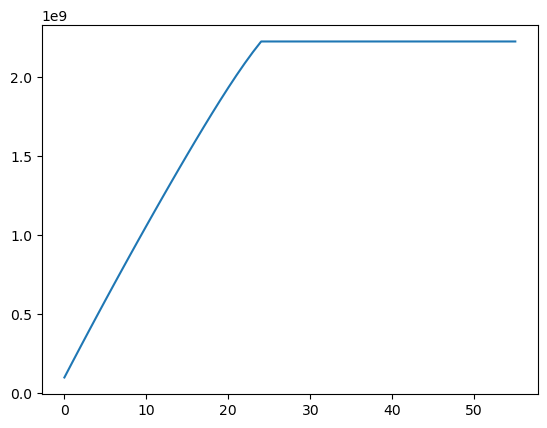

In [12]:
plt.plot(r1.scenario['standard'].dataOut_m['Effective_Capacity_[W]'])

In [13]:
def readPVICEFile(file):

    csvdata = open(str(file), 'r', encoding="UTF-8")
    csvdata = open(str(file), 'r', encoding="UTF-8-sig")
    firstline = csvdata.readline()
    secondline = csvdata.readline()

    head = firstline.rstrip('\n').split(",")
    meta = dict(zip(head, secondline.rstrip('\n').split(",")))

    data = pd.read_csv(csvdata, names=head)
    data.loc[:, data.columns != 'year'] = data.loc[:, data.columns !=
                                                   'year'].astype(float)

    return data, meta

inv_df, inv_meta = readPVICEFile(r'C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines\inverter\baseline_inverter_mass_utility_dummy.csv')

In [14]:
inv_qty = inv_df['year'].to_frame(name='year')

In [15]:
inv_capacity = inv_df['year'].to_frame(name='year')

In [16]:
inv_df.set_index('year', inplace=True)
inv_qty.set_index('year', inplace=True)
inv_capacity.set_index('year', inplace=True)

inv_df['effective_capacity_W'] = list(r1.scenario['standard'].dataOut_m['Effective_Capacity_[W]'])
inv_df['new_Installed_Capacity_W'] = list(r1.scenario['standard'].dataIn_m['new_Installed_Capacity_[MW]']*1e6)


In [17]:
# Make initial installs and life dataframe

for ii in range (0, 15):#len(inv_qty)):
    idxyr = inv_df.index[ii]
    inv_qty[str(idxyr)+'_model_infield'] = 0
    # New Additions"
    inv_qty.loc[idxyr:idxyr+inv_df.loc[idxyr,'inv_lifetime'],str(idxyr)+'_model_infield'] = (
                                                        inv_df.loc[idxyr,'new_Installed_Capacity_W']/inv_df.loc[idxyr,'Inv_per_mod_Area'])

    # Right now this is the same as the new installed capacity; if we round up inverter numbers it would change slightly.
    inv_capacity.loc[idxyr:idxyr+inv_df.loc[idxyr,'inv_lifetime'],str(idxyr)+'_model_infield'] = (
        inv_qty.loc[idxyr:idxyr+inv_df.loc[idxyr,'inv_lifetime'],str(idxyr)+'_model_infield']*inv_df.loc[idxyr,'Inv_per_mod_Area'])
    

In [18]:
inv_capacity['Cumulative_Capacity'] = inv_capacity.sum(axis=1)

In [19]:
inv_capacity

,1995_model_infield,1996_model_infield,1997_model_infield,1998_model_infield,1999_model_infield,2000_model_infield,2001_model_infield,2002_model_infield,2003_model_infield,2004_model_infield,2005_model_infield,2006_model_infield,2007_model_infield,2008_model_infield,2009_model_infield,Cumulative_Capacity
year,,,,,,,,,,,,,,,,
1995,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+08
1996,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+08
1997,100000000.0,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+08
1998,100000000.0,100000000.0,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000e+08
1999,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+08
2000,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000e+08
2001,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000e+08
2002,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000e+08
2003,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0,NaN,NaN,NaN,NaN,NaN,NaN,9.000000e+08


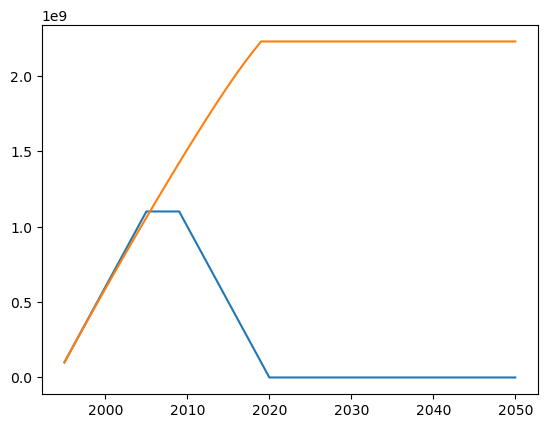

In [20]:
plt.plot(inv_capacity['Cumulative_Capacity'])
plt.plot(inv_df['effective_capacity_W'])

In [26]:
#inv_capacity['Cumulative_Capacity']
inv_df['effective_capacity_W']

year
1995    1.000000e+08
1996    1.992500e+08
1997    2.977556e+08
1998    3.955225e+08
1999    4.925560e+08
2000    5.888616e+08
2001    6.844443e+08
2002    7.793083e+08
2003    8.734566e+08
2004    9.668894e+08
2005    1.059603e+09
2006    1.151586e+09
2007    1.242819e+09
2008    1.333265e+09
2009    1.422869e+09
2010    1.511545e+09
2011    1.599174e+09
2012    1.685584e+09
2013    1.770545e+09
2014    1.853755e+09
2015    1.934824e+09
2016    2.013267e+09
2017    2.088497e+09
2018    2.159830e+09
2019    2.226501e+09
2020    2.226501e+09
2021    2.226501e+09
2022    2.226501e+09
2023    2.226501e+09
2024    2.226501e+09
2025    2.226501e+09
2026    2.226501e+09
2027    2.226501e+09
2028    2.226501e+09
2029    2.226501e+09
2030    2.226501e+09
2031    2.226501e+09
2032    2.226501e+09
2033    2.226501e+09
2034    2.226501e+09
2035    2.226501e+09
2036    2.226501e+09
2037    2.226501e+09
2038    2.226501e+09
2039    2.226501e+09
2040    2.226501e+09
2041    2.226501e+09
2042    